In [ ]:
import os
import json
import re
from getpass import getpass
from typing import TypedDict, Dict, Any, List, Literal

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

In [18]:
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)

### Create sample tickets dataset

In [ ]:
tickets_data = [
    {
        "ticket_id": "T001",
        "customer_name": "Amina Rahman",
        "channel": "email",
        "customer_tier": "standard",
        "created_at": "2026-04-15 09:10",
        "message": "I was charged twice for my monthly subscription. Please fix this and refund the extra payment."
    },
    {
        "ticket_id": "T002",
        "customer_name": "Hasan Ahmed",
        "channel": "chat",
        "customer_tier": "premium",
        "created_at": "2026-04-15 09:25",
        "message": "My parcel still shows in transit after 8 days and the tracking page has not updated. I need this urgently."
    },
    {
        "ticket_id": "T003",
        "customer_name": "Nusrat Jahan",
        "channel": "email",
        "customer_tier": "standard",
        "created_at": "2026-04-15 09:40",
        "message": "I cannot log in to my account even after resetting my password twice. It says account not found."
    },
    {
        "ticket_id": "T004",
        "customer_name": "Rafiul Islam",
        "channel": "web",
        "customer_tier": "standard",
        "created_at": "2026-04-15 10:05",
        "message": "The app keeps crashing when I open the payment section. I tried reinstalling but the issue remains."
    },
    {
        "ticket_id": "T005",
        "customer_name": "Sadia Karim",
        "channel": "email",
        "customer_tier": "premium",
        "created_at": "2026-04-15 10:18",
        "message": "I cancelled my order within an hour but I still have not received my refund. Please update me."
    },
    {
        "ticket_id": "T006",
        "customer_name": "Mahin Chowdhury",
        "channel": "chat",
        "customer_tier": "standard",
        "created_at": "2026-04-15 10:42",
        "message": "The delivery agent marked my package delivered but nothing arrived at my address."
    }
]

tickets_df = pd.DataFrame(tickets_data)
tickets_df

,ticket_id,customer_name,channel,customer_tier,created_at,message
0,T001,Amina Rahman,email,standard,2026-04-15 09:10,I was charged twice for my monthly subscription. Please fix this and refund the extra payment.
1,T002,Hasan Ahmed,chat,premium,2026-04-15 09:25,My parcel still shows in transit after 8 days and the tracking page has not updated. I need this urgently.
2,T003,Nusrat Jahan,email,standard,2026-04-15 09:40,I cannot log in to my account even after resetting my password twice. It says account not found.
3,T004,Rafiul Islam,web,standard,2026-04-15 10:05,The app keeps crashing when I open the payment section. I tried reinstalling but the issue remains.
4,T005,Sadia Karim,email,premium,2026-04-15 10:18,I cancelled my order within an hour but I still have not received my refund. Please update me.
5,T006,Mahin Chowdhury,chat,standard,2026-04-15 10:42,The delivery agent marked my package delivered but nothing arrived at my address.


### Define structured schemas

In [ ]:
class TicketInput(BaseModel):
    ticket_id: str
    customer_name: str
    channel: str
    customer_tier: str
    created_at: str
    message: str

class TicketClassification(BaseModel):
    category: Literal[
        "Billing",
        "Delivery",
        "Refund",
        "Technical Issue",
        "Account Access",
        "Other"
    ]
    sentiment: Literal["Calm", "Frustrated", "Angry", "Urgent"]
    summary: str
    reason: str

class TicketSeverity(BaseModel):
    urgency_score: int = Field(ge=1, le=5)
    priority: Literal["P1", "P2", "P3", "P4", "P5"]
    severity_reason: str
    escalation_needed: bool

class TicketAction(BaseModel):
    next_action: str
    owner_team: Literal[
        "Billing Team",
        "Delivery Team",
        "Refund Team",
        "Technical Support",
        "Account Security",
        "General Support"
    ]
    sla_hours: int
    internal_note: str

class TicketResponse(BaseModel):
    response_draft: str

class TicketTriageOutput(BaseModel):
    ticket_id: str
    category: str
    sentiment: str
    urgency_score: int
    priority: str
    escalation_needed: bool
    owner_team: str
    next_action: str
    sla_hours: int
    summary: str
    internal_note: str
    response_draft: str

### Create helper functions

In [ ]:
def clean_text(text):
    return re.sub(r"\s+", " ", str(text)).strip()

def normalize_ticket_dict(row):
    item = TicketInput(
        ticket_id=clean_text(row.get("ticket_id", "")),
        customer_name=clean_text(row.get("customer_name", "")),
        channel=clean_text(row.get("channel", "")),
        customer_tier=clean_text(row.get("customer_tier", "")),
        created_at=clean_text(row.get("created_at", "")),
        message=clean_text(row.get("message", ""))
    )
    return item.model_dump()

def priority_from_score(score):
    mapping = {
        5: "P1",
        4: "P2",
        3: "P3",
        2: "P4",
        1: "P5"
    }
    return mapping[int(score)]

def derive_rule_signals(ticket):
    text = ticket["message"].lower()

    urgent_keywords = [
        "urgent", "immediately", "asap", "today", "blocking", "cannot access",
        "can't access", "unauthorized", "hacked", "charged twice", "double charged",
        "delivered but nothing arrived", "account not found", "refund", "crashing",
        "error", "not receiving", "not received"
    ]

    security_keywords = [
        "unauthorized", "someone changed", "hacked", "suspicious", "security"
    ]

    blocked_keywords = [
        "cannot log in", "cannot login", "cannot access", "blocked", "account not found",
        "keeps crashing", "throws an error", "blocking our work"
    ]

    refund_keywords = [
        "refund", "charged twice", "extra fee", "invoice", "payment"
    ]

    hits = [word for word in urgent_keywords if word in text]
    security_hits = [word for word in security_keywords if word in text]
    blocked_hits = [word for word in blocked_keywords if word in text]
    refund_hits = [word for word in refund_keywords if word in text]

    base_score = 1

    if hits:
        base_score = max(base_score, 3)

    if blocked_hits:
        base_score = max(base_score, 4)

    if security_hits:
        base_score = max(base_score, 5)

    if ticket["customer_tier"].lower() == "premium":
        base_score = min(5, base_score + 1)

    if "!" in ticket["message"]:
        base_score = min(5, base_score + 1)

    return {
        "rule_hits": hits,
        "security_hits": security_hits,
        "blocked_hits": blocked_hits,
        "refund_hits": refund_hits,
        "rule_score": int(base_score),
        "suggested_priority": priority_from_score(base_score)
    }

def make_markdown_card(data):
    text = []
    text.append(f"## Ticket {data['ticket_id']}")
    text.append("")
    text.append(f"**Category:** {data['category']}")
    text.append(f"**Sentiment:** {data['sentiment']}")
    text.append(f"**Urgency Score:** {data['urgency_score']}")
    text.append(f"**Priority:** {data['priority']}")
    text.append(f"**Escalation Needed:** {data['escalation_needed']}")
    text.append(f"**Owner Team:** {data['owner_team']}")
    text.append(f"**Next Action:** {data['next_action']}")
    text.append(f"**SLA Hours:** {data['sla_hours']}")
    text.append("")
    text.append("### Summary")
    text.append(data["summary"])
    text.append("")
    text.append("### Internal Note")
    text.append(data["internal_note"])
    text.append("")
    text.append("### Draft Response")
    text.append(data["response_draft"])
    return "\n".join(text)

### Define ticket workflow state

In [ ]:
class TicketState(TypedDict):
    raw_ticket: Dict[str, Any]
    ticket: Dict[str, Any]
    rule_signals: Dict[str, Any]
    classification: Dict[str, Any]
    severity: Dict[str, Any]
    action: Dict[str, Any]
    response: Dict[str, Any]
    final_output: Dict[str, Any]

In [ ]:
def normalize_ticket_node(state: TicketState):
    ticket = normalize_ticket_dict(state["raw_ticket"])
    signals = derive_rule_signals(ticket)
    return {
        "ticket": ticket,
        "rule_signals": signals
    }

def classify_ticket_node(state: TicketState):
    model = llm.with_structured_output(TicketClassification)

    prompt = f"""
You classify customer support tickets.

Ticket:
{json.dumps(state["ticket"], indent=2, ensure_ascii=False)}

Allowed categories:
Billing
Delivery
Refund
Technical Issue
Account Access
Other

Return:
- category
- sentiment
- short summary
- short reason

Choose the single best category.
"""
    result = model.invoke(prompt)

    return {
        "classification": result.model_dump()
    }

def score_severity_node(state: TicketState):
    model = llm.with_structured_output(TicketSeverity)

    prompt = f"""
You assign urgency and priority for a customer support ticket.

Ticket:
{json.dumps(state["ticket"], indent=2, ensure_ascii=False)}

Classification:
{json.dumps(state["classification"], indent=2, ensure_ascii=False)}

Rule signals:
{json.dumps(state["rule_signals"], indent=2, ensure_ascii=False)}

Scoring guide:
1 = low urgency, informational
2 = minor issue, can wait
3 = moderate issue, customer impact
4 = high urgency, blocked flow or strong frustration
5 = critical, security risk, account takeover, major access issue, severe business impact

Priority mapping:
5 -> P1
4 -> P2
3 -> P3
2 -> P4
1 -> P5

Rules:
- Consider both ticket meaning and rule signals
- Security or unauthorized access can justify 5
- Blocked access or work-stopping issues can justify 4 or 5
- Billing or refund delays are usually 2 to 4 depending on impact
- Keep the output practical
"""
    result = model.invoke(prompt)

    fixed = result.model_dump()
    fixed["priority"] = priority_from_score(fixed["urgency_score"])

    return {
        "severity": fixed
    }

def suggest_action_node(state: TicketState):
    model = llm.with_structured_output(TicketAction)

    prompt = f"""
You suggest the next internal support action.

Ticket:
{json.dumps(state["ticket"], indent=2, ensure_ascii=False)}

Classification:
{json.dumps(state["classification"], indent=2, ensure_ascii=False)}

Severity:
{json.dumps(state["severity"], indent=2, ensure_ascii=False)}

Return:
- next_action
- owner_team
- sla_hours
- internal_note

Guidance:
- Billing -> Billing Team
- Delivery -> Delivery Team
- Refund -> Refund Team
- Technical Issue -> Technical Support
- Account Access -> Account Security
- Other -> General Support

SLA guidance:
- P1: within 1 hour
- P2: within 4 hours
- P3: within 12 hours
- P4: within 24 hours
- P5: within 48 hours
"""
    result = model.invoke(prompt)

    return {
        "action": result.model_dump()
    }

def draft_response_node(state: TicketState):
    model = llm.with_structured_output(TicketResponse)

    prompt = f"""
You write a professional customer support response.

Ticket:
{json.dumps(state["ticket"], indent=2, ensure_ascii=False)}

Classification:
{json.dumps(state["classification"], indent=2, ensure_ascii=False)}

Severity:
{json.dumps(state["severity"], indent=2, ensure_ascii=False)}

Action:
{json.dumps(state["action"], indent=2, ensure_ascii=False)}

Rules:
- Be empathetic and clear
- Do not promise impossible outcomes
- Mention the immediate next step
- Keep it concise
- Sound professional and supportive
"""
    result = model.invoke(prompt)

    return {
        "response": result.model_dump()
    }

def assemble_output_node(state: TicketState):
    package = TicketTriageOutput(
        ticket_id=state["ticket"]["ticket_id"],
        category=state["classification"]["category"],
        sentiment=state["classification"]["sentiment"],
        urgency_score=state["severity"]["urgency_score"],
        priority=state["severity"]["priority"],
        escalation_needed=state["severity"]["escalation_needed"],
        owner_team=state["action"]["owner_team"],
        next_action=state["action"]["next_action"],
        sla_hours=state["action"]["sla_hours"],
        summary=state["classification"]["summary"],
        internal_note=state["action"]["internal_note"],
        response_draft=state["response"]["response_draft"]
    )

    return {
        "final_output": package.model_dump()
    }

In [32]:
# Build the LangGraph workflow
builder = StateGraph(TicketState)

builder.add_node("normalize_ticket", normalize_ticket_node)
builder.add_node("classify_ticket", classify_ticket_node)
builder.add_node("score_severity", score_severity_node)
builder.add_node("suggest_action", suggest_action_node)
builder.add_node("draft_response", draft_response_node)
builder.add_node("assemble_output", assemble_output_node)

builder.add_edge(START, "normalize_ticket")
builder.add_edge("normalize_ticket", "classify_ticket")
builder.add_edge("classify_ticket", "score_severity")
builder.add_edge("score_severity", "suggest_action")
builder.add_edge("suggest_action", "draft_response")
builder.add_edge("draft_response", "assemble_output")
builder.add_edge("assemble_output", END)

ticket_graph = builder.compile()

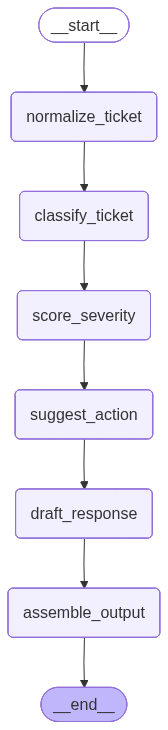

In [33]:
ticket_graph

In [34]:
# Run triage on all tickets
triage_results = []

for row in tickets_df.to_dict(orient="records"):
    result = ticket_graph.invoke(
        {
            "raw_ticket": row,
            "ticket": {},
            "rule_signals": {},
            "classification": {},
            "severity": {},
            "action": {},
            "response": {},
            "final_output": {}
        }
    )
    triage_results.append(result["final_output"])

triage_df = pd.DataFrame(triage_results)
triage_df

,ticket_id,category,sentiment,urgency_score,priority,escalation_needed,owner_team,next_action,sla_hours,summary,internal_note,response_draft
0,T001,Billing,Frustrated,3,P3,False,Billing Team,Investigate duplicate charge and process refund.,12,Customer was double-charged for their monthly subscription and requests a refund for the extra payment.,Customer was double-charged for their monthly subscription. The Billing Team needs to investigate the duplicate charge and process a refund for the extra payment. Customer is frustrated.,"Dear Amina Rahman,\n\nThank you for reaching out. I understand your frustration regarding the duplicate charge for your monthly subscription, and I sincerely apologize for this inconvenience.\n\nP..."
1,T002,Delivery,Urgent,4,P2,False,Delivery Team,Investigate parcel status and tracking update with the shipping carrier. Provide an estimated delivery date to the customer.,4,"Parcel delayed for 8 days, tracking not updated, urgent delivery needed.",Premium customer Hasan Ahmed (T002) reporting an 8-day parcel delay with no tracking updates. P2 priority due to urgency. Delivery Team needs to contact the carrier for an immediate update and com...,"Dear Hasan Ahmed,\n\nI'm very sorry to hear that your parcel (T002) is still in transit after 8 days and the tracking information hasn't been updated. I understand how frustrating this must be, es..."
2,T003,Account Access,Frustrated,5,P1,True,Account Security,Investigate account status and potential system-level issue preventing login for the customer.,1,"Customer cannot log in, account not found after multiple password resets.",Customer reports persistent 'account not found' error despite multiple password resets. This is a P1 issue requiring immediate investigation by the Account Security team to verify account existenc...,"Dear Nusrat Jahan,\n\nI understand how frustrating it must be to be unable to log in to your account, especially after resetting your password multiple times and still encountering an ""account not..."
3,T004,Technical Issue,Frustrated,4,P2,True,Technical Support,Investigate app crash logs and device specifications for root cause.,4,"Customer reports app crashing consistently when trying to access the payment section, even after reinstalling.","Customer reports app crashing consistently when trying to access the payment section, even after reinstalling. This is a critical issue blocking a core app function. Priority P2 due to high impact...","Dear Rafiul Islam,\n\nThank you for reaching out. I'm truly sorry to hear that our app keeps crashing when you try to access the payment section, and that reinstalling didn't resolve the issue. I ..."
4,T005,Refund,Calm,4,P2,False,Refund Team,Investigate refund status for cancelled order and process if applicable.,4,Customer cancelled an order but has not yet received their refund.,Premium customer reported not receiving a refund after cancelling an order within an hour. Please check the refund system for T005 and expedite the refund process.,"Dear Sadia Karim,\n\nThank you for contacting us. I understand you are concerned about the status of your refund for order T005, which you cancelled within the hour. \n\nPlease be assured that we ..."
5,T006,Delivery,Frustrated,4,P2,False,Delivery Team,"Investigate delivery status with carrier, cross-reference GPS data if available, and provide an update to the customer regarding the package's whereabouts.",4,Package marked delivered but not received by customer.,Customer states package was marked delivered but not received. Priority P2. Contact delivery carrier immediately to investigate the discrepancy. Check delivery driver's route and GPS confirmation....,"Dear Mahin Chowdhury,\n\nThank you for reaching out to us regarding your recent delivery (Ticket T006). I understand your frustration and concern that your package was marked as delivered but has ..."


In [35]:
# Create dashboard table
dashboard_df = tickets_df.merge(triage_df, on="ticket_id", how="left")
dashboard_df = dashboard_df[
    [
        "ticket_id",
        "customer_name",
        "channel",
        "customer_tier",
        "category",
        "sentiment",
        "urgency_score",
        "priority",
        "escalation_needed",
        "owner_team",
        "sla_hours",
        "next_action"
    ]
]
dashboard_df.sort_values(["urgency_score", "ticket_id"], ascending=[False, True])

,ticket_id,customer_name,channel,customer_tier,category,sentiment,urgency_score,priority,escalation_needed,owner_team,sla_hours,next_action
2,T003,Nusrat Jahan,email,standard,Account Access,Frustrated,5,P1,True,Account Security,1,Investigate account status and potential system-level issue preventing login for the customer.
1,T002,Hasan Ahmed,chat,premium,Delivery,Urgent,4,P2,False,Delivery Team,4,Investigate parcel status and tracking update with the shipping carrier. Provide an estimated delivery date to the customer.
3,T004,Rafiul Islam,web,standard,Technical Issue,Frustrated,4,P2,True,Technical Support,4,Investigate app crash logs and device specifications for root cause.
4,T005,Sadia Karim,email,premium,Refund,Calm,4,P2,False,Refund Team,4,Investigate refund status for cancelled order and process if applicable.
5,T006,Mahin Chowdhury,chat,standard,Delivery,Frustrated,4,P2,False,Delivery Team,4,"Investigate delivery status with carrier, cross-reference GPS data if available, and provide an update to the customer regarding the package's whereabouts."
0,T001,Amina Rahman,email,standard,Billing,Frustrated,3,P3,False,Billing Team,12,Investigate duplicate charge and process refund.


In [36]:
# Show highest priority tickets
high_priority_df = dashboard_df[dashboard_df["priority"].isin(["P1", "P2"])].sort_values(
    ["urgency_score", "ticket_id"],
    ascending=[False, True]
)
high_priority_df

,ticket_id,customer_name,channel,customer_tier,category,sentiment,urgency_score,priority,escalation_needed,owner_team,sla_hours,next_action
2,T003,Nusrat Jahan,email,standard,Account Access,Frustrated,5,P1,True,Account Security,1,Investigate account status and potential system-level issue preventing login for the customer.
1,T002,Hasan Ahmed,chat,premium,Delivery,Urgent,4,P2,False,Delivery Team,4,Investigate parcel status and tracking update with the shipping carrier. Provide an estimated delivery date to the customer.
3,T004,Rafiul Islam,web,standard,Technical Issue,Frustrated,4,P2,True,Technical Support,4,Investigate app crash logs and device specifications for root cause.
4,T005,Sadia Karim,email,premium,Refund,Calm,4,P2,False,Refund Team,4,Investigate refund status for cancelled order and process if applicable.
5,T006,Mahin Chowdhury,chat,standard,Delivery,Frustrated,4,P2,False,Delivery Team,4,"Investigate delivery status with carrier, cross-reference GPS data if available, and provide an update to the customer regarding the package's whereabouts."


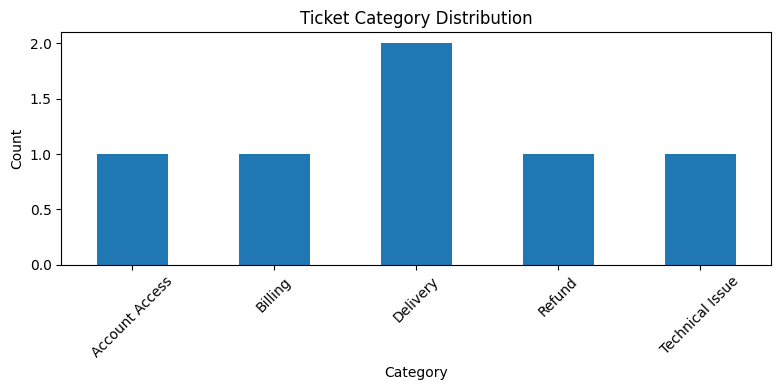

In [37]:
# Plot category distribution
category_counts = triage_df["category"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
category_counts.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Ticket Category Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

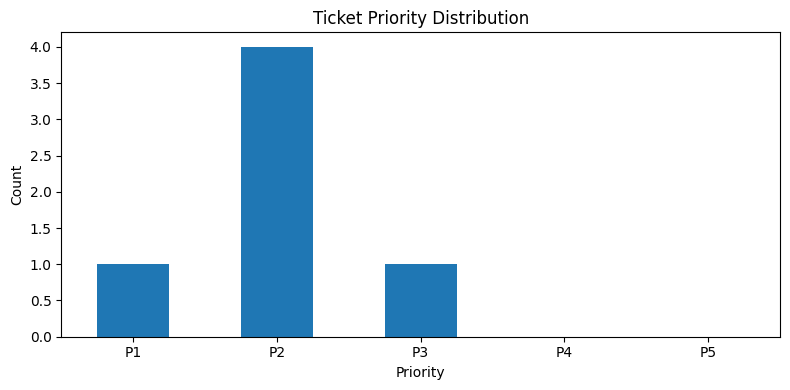

In [38]:
# Plot priority distribution
priority_order = ["P1", "P2", "P3", "P4", "P5"]
priority_counts = triage_df["priority"].value_counts().reindex(priority_order, fill_value=0)

plt.figure(figsize=(8, 4))
priority_counts.plot(kind="bar")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.title("Ticket Priority Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
# Show full detail for one ticket
selected_ticket_id = "T004"

selected_row = triage_df[triage_df["ticket_id"] == selected_ticket_id].iloc[0].to_dict()
display(Markdown(make_markdown_card(selected_row)))

## Ticket T004

**Category:** Technical Issue
**Sentiment:** Frustrated
**Urgency Score:** 4
**Priority:** P2
**Escalation Needed:** True
**Owner Team:** Technical Support
**Next Action:** Investigate app crash logs and device specifications for root cause.
**SLA Hours:** 4

### Summary
Customer reports app crashing consistently when trying to access the payment section, even after reinstalling.

### Internal Note
Customer reports app crashing consistently when trying to access the payment section, even after reinstalling. This is a critical issue blocking a core app function. Priority P2 due to high impact and customer frustration. Please gather device details and app logs for immediate investigation.

### Draft Response
Dear Rafiul Islam,

Thank you for reaching out. I'm truly sorry to hear that our app keeps crashing when you try to access the payment section, and that reinstalling didn't resolve the issue. I understand how frustrating this must be, especially for such an important function.

Please rest assured that our technical team is now actively investigating this issue to identify the root cause. We will gather the necessary information and work towards a resolution as quickly as possible.

We appreciate your patience and will keep you informed of our progress.

Sincerely,
Customer Support Team

In [41]:
# Show triage output as json
selected_ticket_id = "T005"

selected_json = triage_df[triage_df["ticket_id"] == selected_ticket_id].iloc[0].to_dict()
print(json.dumps(selected_json, indent=2, ensure_ascii=False))

{
  "ticket_id": "T005",
  "category": "Refund",
  "sentiment": "Calm",
  "urgency_score": 4,
  "priority": "P2",
  "escalation_needed": false,
  "owner_team": "Refund Team",
  "next_action": "Investigate refund status for cancelled order and process if applicable.",
  "sla_hours": 4,
  "summary": "Customer cancelled an order but has not yet received their refund.",
  "internal_note": "Premium customer reported not receiving a refund after cancelling an order within an hour. Please check the refund system for T005 and expedite the refund process.",
  "response_draft": "Dear Sadia Karim,\n\nThank you for contacting us. I understand you are concerned about the status of your refund for order T005, which you cancelled within the hour. \n\nPlease be assured that we are actively investigating this for you. Our Refund Team is looking into the details to ensure your refund is processed as quickly as possible.\n\nWe will provide you with an update as soon as we have more information. We apprec